# 结果分析与结论

本节分析减少输入后的检测表现、计算开销，以及结果与具体输入的联系，并分别检查模型随机性、重复计时和数据划分变化是否影响比较。

不同版本的标签和预测不能混在一起比较。所以先核对结果文件与测试记录，再按保存的预测重新计算指标。正常为 0，攻击为 1。FP 表示正常被误报为攻击，FN 表示攻击被漏报为正常。[混淆矩阵定义](https://scikit-learn.org/stable/modules/model_evaluation.html#confusion-matrix)说明了真实类别与预测类别的对应关系。


In [1]:
# 1.读取结果并核对测试记录和评价指标
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score,
    recall_score, matthews_corrcoef,
)

root = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data/processed/model_inputs.npz").is_file())
source_dir = root / "results/03_features_and_models"
source_names = [
    "tables/results_summary.csv", "arrays/test_predictions.npz", "metadata/experiment_settings.json",
    "tables/attack_type_recall.csv", "tables/fs_selected_features.csv", "tables/fs_thresholds.csv",
    "tables/feature_scores.csv", "tables/pca_variance.csv", "tables/pca_loadings.csv",
    "tables/fs_pca_comparison.csv",
]
source_paths = [source_dir / name for name in source_names]
assert all(path.is_file() for path in source_paths), "03 的结果文件不完整"
source_hashes = {str(path.relative_to(source_dir)): hashlib.sha256(path.read_bytes()).hexdigest()
                 for path in source_paths}
settings = json.loads((source_dir / "metadata/experiment_settings.json").read_text())
results = pd.read_csv(source_dir / "tables/results_summary.csv")
saved_attack = pd.read_csv(source_dir / "tables/attack_type_recall.csv")
selected = pd.read_csv(source_dir / "tables/fs_selected_features.csv")
thresholds = pd.read_csv(source_dir / "tables/fs_thresholds.csv")
feature_scores = pd.read_csv(source_dir / "tables/feature_scores.csv")
variance = pd.read_csv(source_dir / "tables/pca_variance.csv")
loadings = pd.read_csv(source_dir / "tables/pca_loadings.csv")
assert settings["split"] == "exact_input_group_holdout"
input_path = root / settings["input_file"]
assert hashlib.sha256(input_path.read_bytes()).hexdigest() == settings["input_sha256"]
with np.load(input_path, allow_pickle=False) as inputs:
    test_labels = inputs["group_y_test"].copy()
    test_index = inputs["group_test_index"].copy()
    test_types = inputs["group_test_type"].copy()
    feature_names = inputs["group_feature_names"].copy()
    input_columns = inputs["input_fields"].copy()
    train_labels = inputs["group_y_train"].copy()
    assert inputs["raw_sha256"].item() == settings["raw_sha256"]
    assert int(inputs["random_seed"].item()) == settings["random_seed"]
with np.load(source_dir / "arrays/test_predictions.npz", allow_pickle=False) as saved:
    np.testing.assert_array_equal(saved["y_test"], test_labels)
    np.testing.assert_array_equal(saved["test_index"], test_index)
    np.testing.assert_array_equal(saved["test_type"], test_types)
    predictions = {name: saved[name].copy() for name in saved.files
                   if name not in {"y_test", "test_index", "test_type"}}
assert np.array_equal(test_labels, (test_types != "normal").astype(np.int8))
assert set(np.unique(test_labels)) == {0, 1}
assert len(np.unique(test_index)) == len(test_index)
assert len(train_labels) == settings["train_rows"]
assert len(test_labels) == settings["test_rows"]
assert feature_names.tolist() == settings["feature_names"]
original_dimensions = settings["original_dimensions"]
dimensions = settings["fs_dimensions"]
pca_dimensions = settings["pca_dimensions"]
models = list(settings["model_parameters"])
assert set(models) == {"DT", "RF"}
assert results["随机种子"].eq(settings["random_seed"]).all()
assert original_dimensions == len(feature_names)
assert len(dimensions) == len(set(dimensions))
assert all(0 < size < original_dimensions for size in dimensions)
assert settings["model_parameters"]["DT"]["max_depth"] is None
assert settings["model_parameters"]["RF"]["max_depth"] == 5
scheme_order = [("Original", original_dimensions)]
for size in dimensions:
    scheme_order.extend([("FS", size), ("PCA", size)])
scheme_order.append(("PCA", original_dimensions))
key_columns = ["模型", "输入方案", "维数"]
expected_keys = [(model, method, size) for model in models
                 for method, size in scheme_order]
assert not results.duplicated(key_columns).any()
assert set(map(tuple, results[key_columns].to_numpy())) == set(expected_keys)
assert len(results) == settings["result_rows"]
results = results.set_index(key_columns).loc[expected_keys].reset_index()
def prediction_key(model, method, size):
    return f"{model}_{method}_{int(size)}"
assert set(predictions) == {prediction_key(*key) for key in expected_keys}
metric_columns = ["Macro-F1", "攻击召回率", "攻击精确率", "Accuracy", "Weighted-F1", "MCC"]
check_rows = []
for _, row in results.iterrows():
    pred = predictions[prediction_key(*(row[name] for name in key_columns))]
    assert pred.shape == test_labels.shape and set(np.unique(pred)) <= {0, 1}
    tn, fp, fn, tp = confusion_matrix(test_labels, pred, labels=[0, 1]).ravel()
    np.testing.assert_array_equal([tn, fp, fn, tp], row[["TN", "FP", "FN", "TP"]].to_numpy())
    measured = [
        f1_score(test_labels, pred, average="macro", zero_division=0),
        recall_score(test_labels, pred, pos_label=1, zero_division=0),
        precision_score(test_labels, pred, pos_label=1, zero_division=0),
        accuracy_score(test_labels, pred),
        f1_score(test_labels, pred, average="weighted", zero_division=0),
        matthews_corrcoef(test_labels, pred),
    ]
    np.testing.assert_allclose(measured, row[metric_columns].to_numpy(dtype=float),
                               rtol=1e-12, atol=1e-12)
    check_rows.append({**{name: row[name] for name in key_columns},
                       "核对测试记录数": len(pred), "混淆矩阵与六项指标": "一致"})
result_check = pd.DataFrame(check_rows)

def show_table(table, decimals=6):
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.max_colwidth", None):
        display(table.style.format(precision=decimals, na_rep="不适用").hide(axis="index"))

scope_table = pd.DataFrame([
    {"数据": "隔离训练集", "记录数": len(train_labels), "输入列数": len(feature_names),
     "正常记录数": int((train_labels == 0).sum()), "攻击记录数": int((train_labels == 1).sum())},
    {"数据": "隔离测试集", "记录数": len(test_labels), "输入列数": len(feature_names),
     "正常记录数": int((test_labels == 0).sum()), "攻击记录数": int((test_labels == 1).sum())},
])
show_table(scope_table)
show_table(result_check)

数据,记录数,输入列数,正常记录数,攻击记录数
隔离训练集,360464,88,230538,129926
隔离测试集,89508,88,58391,31117


模型,输入方案,维数,核对测试记录数,混淆矩阵与六项指标
DT,Original,88,89508,一致
DT,FS,10,89508,一致
DT,PCA,10,89508,一致
DT,FS,33,89508,一致
DT,PCA,33,89508,一致
DT,FS,45,89508,一致
DT,PCA,45,89508,一致
DT,FS,69,89508,一致
DT,PCA,69,89508,一致
DT,PCA,88,89508,一致


结论：20 个实验的测试记录、四类计数和六项指标核对一致。结果对应同一份隔离划分。训练集有 360,464 条记录，测试集有 89,508 条记录，Original 保留 88 列输入。

02 已完成编码、缩放和隔离划分，03 已保存各方案的预测。第 2 至 7 步直接使用种子 42 的原实验结果，不再清洗数据或重复训练。Original 表示保留全部输入，FS 表示 Pearson 特征选择，PCA 表示主成分分析。

只看降维后的分数，无法判断相对全部输入发生了什么变化。所以接下来以同模型的 Original 为基线，比较全部方案的检测指标。

Macro-F1 同时考虑正常和攻击两类，攻击召回率反映实际攻击被检出的比例。为避免只看这两项而忽略误报，表中同时保留攻击精确率、Accuracy、Weighted-F1 和 MCC。差值按当前方案减去同模型 Original 计算，正值表示分数增加。这里采用分数差，不写成相对增长率。

In [2]:
# 2.比较全部方案与同模型 Original 的检测表现
score_table = results[key_columns + metric_columns].copy()
baseline = results[results["输入方案"] == "Original"].set_index("模型")
delta_rows = []
for _, row in results.iterrows():
    delta_rows.append({**{name: row[name] for name in key_columns},
                      **{name + "变化": row[name] - baseline.loc[row["模型"], name]
                         for name in metric_columns}})
score_changes = pd.DataFrame(delta_rows)
for metric in ["Macro-F1", "攻击召回率"]:
    np.testing.assert_allclose(score_changes[metric + "变化"],
                               results["相对Original的" + metric + "变化"], atol=1e-12)
show_table(score_table)
show_table(score_changes)

模型,输入方案,维数,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC
DT,Original,88,0.915203,0.985089,0.820476,0.919884,0.921274,0.840390
DT,FS,10,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537
DT,PCA,10,0.793275,0.848893,0.670738,0.802599,0.806653,0.601361
DT,FS,33,0.773793,0.805444,0.655602,0.785271,0.789319,0.558350
DT,PCA,33,0.806690,0.852749,0.691160,0.816340,0.819851,0.625140
DT,FS,45,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961
DT,PCA,45,0.890437,0.975672,0.779521,0.895607,0.897689,0.795936
DT,FS,69,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945
DT,PCA,69,0.916536,0.987177,0.821820,0.921136,0.922506,0.843127
DT,PCA,88,0.916507,0.986985,0.821880,0.921113,0.922483,0.843039


模型,输入方案,维数,Macro-F1变化,攻击召回率变化,攻击精确率变化,Accuracy变化,Weighted-F1变化,MCC变化
DT,Original,88,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DT,FS,10,-0.157451,-0.226661,-0.173281,-0.147596,-0.145440,-0.318854
DT,PCA,10,-0.121928,-0.136196,-0.149739,-0.117286,-0.114621,-0.239030
DT,FS,33,-0.141410,-0.179645,-0.164875,-0.134614,-0.131955,-0.282040
DT,PCA,33,-0.108513,-0.132339,-0.129317,-0.103544,-0.101423,-0.215250
DT,FS,45,-0.122810,-0.135810,-0.151286,-0.118235,-0.115524,-0.240430
DT,PCA,45,-0.024766,-0.009416,-0.040956,-0.024277,-0.023585,-0.044454
DT,FS,69,-0.006931,-0.011955,-0.006362,-0.006469,-0.006383,-0.014445
DT,PCA,69,0.001333,0.002089,0.001344,0.001251,0.001232,0.002737
DT,PCA,88,0.001304,0.001896,0.001403,0.001229,0.001209,0.002649


结论：模型种子 42 下，DT 的 PCA 88 维 Macro-F1 为 0.916507，Original 为 0.915203。RF 的 PCA 88 维 Macro-F1 为 0.821600，Original 为 0.837757。这组比较的输入数量相同，所以差异不能归因于减少维数。它只描述当前模型配置下改变表示后的结果。其他全部方案及差值也列在上表。

与 Original 比较还不能直接区分 FS 与 PCA。所以下一步比较同模型、同维数的八组降维配对。


In [3]:
# 3.比较同模型、同维数的 FS 与 PCA
result_index = results.set_index(key_columns)
pair_rows = []
for model in models:
    for size in dimensions:
        fs = result_index.loc[(model, "FS", size)]
        pca = result_index.loc[(model, "PCA", size)]
        pair_rows.append({"模型": model, "维数": size,
                          **{"PCA减FS的" + metric: pca[metric] - fs[metric]
                             for metric in metric_columns}})
paired_scores = pd.DataFrame(pair_rows)
stored_pairs = pd.read_csv(source_dir / "tables/fs_pca_comparison.csv").rename(columns={"同条件维数": "维数"})
matched = paired_scores.merge(stored_pairs, on=["模型", "维数"], validate="one_to_one",
                              suffixes=("", "_保存值"))
assert len(matched) == len(paired_scores)
for metric in ["Macro-F1", "攻击召回率"]:
    np.testing.assert_allclose(matched["PCA减FS的" + metric],
                               matched["PCA减FS的" + metric + "_保存值"], atol=1e-12)
show_table(paired_scores)

模型,维数,PCA减FS的Macro-F1,PCA减FS的攻击召回率,PCA减FS的攻击精确率,PCA减FS的Accuracy,PCA减FS的Weighted-F1,PCA减FS的MCC
DT,10,0.035523,0.090465,0.023542,0.030310,0.030818,0.079824
DT,33,0.032897,0.047305,0.035558,0.031070,0.030532,0.066790
DT,45,0.098044,0.126394,0.110330,0.093958,0.091939,0.195976
DT,69,0.008264,0.014044,0.007706,0.007720,0.007616,0.017182
RF,10,0.069175,0.309541,-0.043828,0.036432,0.049606,0.140861
RF,33,0.071879,0.287463,-0.030008,0.042879,0.054172,0.144344
RF,45,0.018634,-0.018896,0.036203,0.020702,0.019573,0.026506
RF,69,0.029454,-0.028795,0.058977,0.032433,0.030656,0.042849


结论：在原模型种子 42 的八组配对中，PCA 的 Macro-F1 均高于同模型、同维数的 FS。攻击召回率的方向并不完全一致。DT 的四组 PCA 均更高；RF 的 PCA 在 10、33 维时更高，在 45、69 维时更低。

所以“PCA 的 Macro-F1 更高”不能直接写成“PCA 的漏报更少”。这个结果也只对应当前 Pearson 选列规则和模型参数，不能推广到所有特征选择方法。

分数差值没有显示具体多错或少错了多少条记录。所以接下来核对全部方案的误报、漏报，并比较它们相对 Original 新增和纠正的错误。

正常误报率等于 FP 除以正常记录数，攻击漏报率等于 FN 除以攻击记录数。对同一条测试记录，Original 判断正确而当前方案判断错误，记为新增错误；反过来记为纠正错误。净变化等于新增错误减去纠正错误，正值表示错误增多，负值表示错误减少。只比较相同模型的预测。Original 与自身比较没有变化，所以新增与纠正表列出全部 18 个非 Original 实验，其中包含两个完整维数 PCA 实验。

In [4]:
# 4.核对误报、漏报以及相对 Original 的错误变化
normal_mask = test_labels == 0
attack_mask = test_labels == 1
error_table = results[key_columns + ["TN", "FP", "FN", "TP"]].copy()
error_table["正常误报率"] = error_table["FP"] / int(normal_mask.sum())
error_table["攻击漏报率"] = error_table["FN"] / int(attack_mask.sum())
np.testing.assert_allclose(error_table["攻击漏报率"], 1 - results["攻击召回率"])
transition_rows = []
for _, row in results[results["输入方案"] != "Original"].iterrows():
    model, method, size = (row[name] for name in key_columns)
    original_pred = predictions[prediction_key(model, "Original", original_dimensions)]
    current_pred = predictions[prediction_key(model, method, size)]
    old_wrong = original_pred != test_labels
    new_wrong = current_pred != test_labels
    entry = {name: row[name] for name in key_columns}
    for name, mask, count_name in [("误报", normal_mask, "FP"), ("漏报", attack_mask, "FN")]:
        added = int((mask & ~old_wrong & new_wrong).sum())
        corrected = int((mask & old_wrong & ~new_wrong).sum())
        entry["新增" + name] = added
        entry["纠正" + name] = corrected
        entry[name + "净变化"] = added - corrected
        assert added - corrected == row[count_name] - baseline.loc[model, count_name]
    transition_rows.append(entry)
error_changes = pd.DataFrame(transition_rows)
show_table(error_table)
show_table(error_changes)

模型,输入方案,维数,TN,FP,FN,TP,正常误报率,攻击漏报率
DT,Original,88,51684,6707,464,30653,0.114864,0.014911
DT,FS,10,45526,12865,7517,23600,0.220325,0.241572
DT,PCA,10,45424,12967,4702,26415,0.222072,0.151107
DT,FS,33,45225,13166,6054,25063,0.225480,0.194556
DT,PCA,33,46534,11857,4582,26535,0.203062,0.147251
DT,FS,45,45327,13064,4690,26427,0.223733,0.150721
DT,PCA,45,49804,8587,757,30360,0.147060,0.024328
DT,FS,69,51477,6914,836,30281,0.118409,0.026866
DT,PCA,69,51731,6660,399,30718,0.114059,0.012823
DT,PCA,88,51735,6656,405,30712,0.113990,0.013015


模型,输入方案,维数,新增误报,纠正误报,误报净变化,新增漏报,纠正漏报,漏报净变化
DT,FS,10,6826,668,6158,7116,63,7053
DT,PCA,10,6824,564,6260,4314,76,4238
DT,FS,33,7019,560,6459,5671,81,5590
DT,PCA,33,5751,601,5150,4202,84,4118
DT,FS,45,6918,561,6357,4308,82,4226
DT,PCA,45,2062,182,1880,567,274,293
DT,FS,69,394,187,207,440,68,372
DT,PCA,69,99,146,-47,174,239,-65
DT,PCA,88,93,144,-51,182,241,-59
RF,FS,10,11,6926,-6915,13900,0,13900


结论：DT 的 Original 有 6,707 条正常误报和 464 条攻击漏报。PCA 69 维对应 6,660 条误报和 399 条漏报，净减少 47 条误报、65 条漏报。净减少不表示原来的错误全部被纠正，新增与纠正的数量见第二张表。

RF 的 Original 攻击召回率为 0.986920，但仍有 13,764 条正常误报。高攻击召回率不能单独说明误报问题已经解决。DT 与 RF 的树深设置不同，这里不据此判断哪一种模型普遍更好。

上述计数将所有攻击合并统计，仍看不出漏报集中在哪些类型。03 已按类型统计，本节沿用其定义，用保存的预测核对这些计数，再绘图比较。接下来只处理这一步。

模型只判断正常或攻击。按攻击类型统计，是检查某一类真实攻击有多少被预测为攻击，并不是让模型识别攻击名称。表格展示全部九种攻击类型和 20 个实验。图中按模型分开，使用相同的 0 到 1 色标，并标出每种攻击的测试记录数。图内数字保留三位小数，接近 1 的值可能显示为 1.000，精确结果以表格中的计数和召回率为准。

模型,输入方案,维数,攻击类型,测试记录数,检出数,漏报数,攻击类型召回率
DT,Original,88,backdoor,4000,3998,2,0.999500
DT,Original,88,ddos,4000,3981,19,0.995250
DT,Original,88,dos,4000,3981,19,0.995250
DT,Original,88,injection,4000,3987,13,0.996750
DT,Original,88,mitm,209,187,22,0.894737
DT,Original,88,password,4000,3987,13,0.996750
DT,Original,88,ransomware,4000,3715,285,0.928750
DT,Original,88,scanning,3277,3256,21,0.993592
DT,Original,88,xss,3631,3561,70,0.980722
DT,FS,10,backdoor,4000,3972,28,0.993000


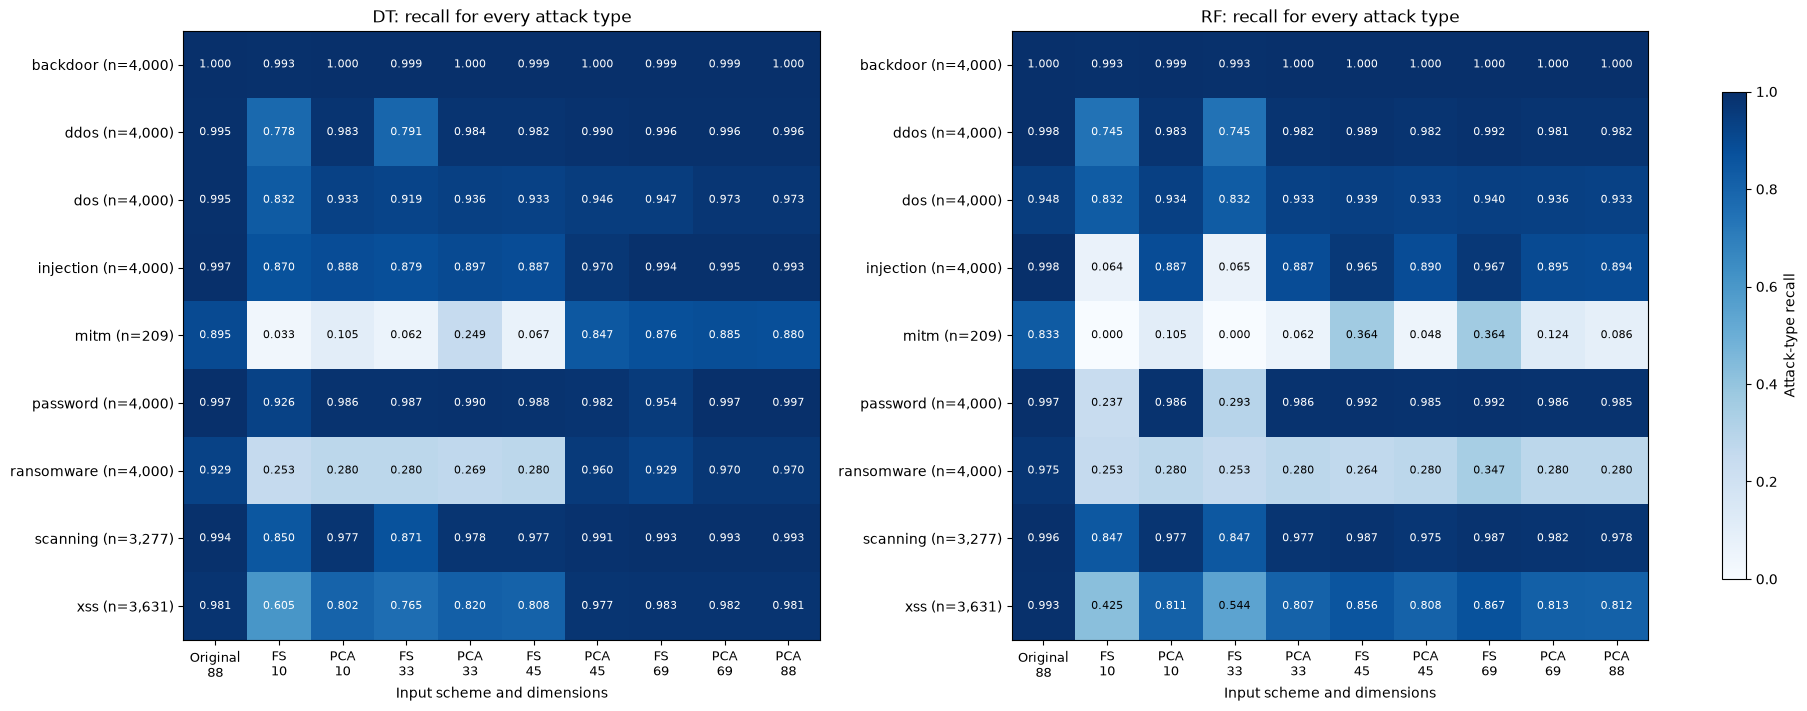

In [5]:
# 5.统计全部攻击类型并比较漏报分布
attack_types = sorted(set(test_types) - {"normal"})
attack_rows = []
for _, row in results.iterrows():
    pred = predictions[prediction_key(*(row[name] for name in key_columns))]
    for traffic_type in attack_types:
        mask = test_types == traffic_type
        total = int(mask.sum())
        detected = int((pred[mask] == 1).sum())
        attack_rows.append({**{name: row[name] for name in key_columns},
                           "攻击类型": traffic_type, "测试记录数": total,
                           "检出数": detected, "漏报数": total - detected,
                           "攻击类型召回率": detected / total})
attack_details = pd.DataFrame(attack_rows)
attack_keys = key_columns + ["攻击类型"]
pd.testing.assert_frame_equal(
    attack_details.sort_values(attack_keys).reset_index(drop=True),
    saved_attack.sort_values(attack_keys).reset_index(drop=True),
    check_exact=False, rtol=1e-12, atol=1e-12,
)
for key, block in attack_details.groupby(key_columns):
    assert block["测试记录数"].sum() == int(attack_mask.sum())
    assert block["检出数"].sum() == result_index.loc[key, "TP"]
    assert block["漏报数"].sum() == result_index.loc[key, "FN"]
show_table(attack_details)

fig_attack, axes = plt.subplots(1, len(models), figsize=(18, 7), layout="constrained")
for ax, model in zip(np.atleast_1d(axes), models):
    block = attack_details[attack_details["模型"] == model]
    matrix = block.pivot(index="攻击类型", columns=["输入方案", "维数"],
                         values="攻击类型召回率").reindex(index=attack_types, columns=scheme_order)
    values = matrix.to_numpy()
    image = ax.imshow(values, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(scheme_order)), [f"{method}\n{size}" for method, size in scheme_order], fontsize=9)
    counts = block.groupby("攻击类型")["测试记录数"].first()
    ax.set_yticks(range(len(attack_types)), [f"{name} (n={counts[name]:,})" for name in attack_types])
    for (i, j), value in np.ndenumerate(values):
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8,
                color="white" if value >= 0.6 else "black")
    ax.set_title(f"{model}: recall for every attack type")
    ax.set_xlabel("Input scheme and dimensions")
fig_attack.colorbar(image, ax=np.atleast_1d(axes).tolist(), label="Attack-type recall", shrink=0.8)
plt.show()

结论：上表和图覆盖全部 180 个“实验与攻击类型”组合。

mitm 的测试记录数在全部攻击类型中最少，只有 209 条，所以先查看它在各方案中的检出情况。它的最高召回率为 0.894737，来自 DT Original。RF 的 FS 10 维和 FS 33 维均未检出 mitm。这说明部分方案的整体分数不能反映该类型的漏报程度。

为了查看同一输入方案在两种模型中的表现是否一致，再以四个降维方案中压缩程度最低的 PCA 69 维逐类型比较。图中 ransomware 的差异较大：DT 为 0.970000，RF 为 0.279750；RF 的 Original 为 0.975250。这个结果说明，不能将某种输入方案在一个模型中的表现直接推给另一个模型。

上述两个例子用于说明小样本类型的漏报和跨模型的差异，不代表其他类型具有相同结果。全部类型仍在表图中展示。

这些统计还不能解释漏报的成因。类型数量、输入表示和模型参数都可能有关，需要后续受控比较才能区分。

检测分数只回答了效果问题，还没有说明为这些结果付出了多少计算时间。所以接下来比较全部方案的维数和耗时。

03 已记录输入准备和模型计算的耗时，这里直接使用已保存的时间，不重新计时。训练总时间为输入准备加模型训练，测试总时间为输入转换加模型预测。计时范围不包含 02 的数据准备、文件读写、指标计算和绘图。输入列减少比例等于（88 − 当前维数）÷ 88，以小数表示。相对 Original 的时间倍数等于当前方案时间除以同模型 Original 时间，小于 1 表示本次更短。展示全部四项时间组成和两项总时间，避免只看模型训练而遗漏降维开销。

为了核对是否有方案同时改善效果和速度，第三张表逐项检查两项主要检测分数是否都提高、训练与测试总时间是否都缩短。只有四项均满足才记为“是”，等于基线不算提高或缩短。展示全部方案，Original 与自身比较作为参照。

In [6]:
# 6.比较全部方案的输入维数和计算开销
time_columns = ["训练准备秒", "模型训练秒", "训练总秒", "测试转换秒", "模型预测秒", "测试总秒"]
time_breakdown = results[key_columns + time_columns].copy()
assert np.isfinite(time_breakdown[time_columns].to_numpy()).all()
assert (time_breakdown[time_columns] >= 0).all().all()
np.testing.assert_allclose(results["训练总秒"], results["训练准备秒"] + results["模型训练秒"])
np.testing.assert_allclose(results["测试总秒"], results["测试转换秒"] + results["模型预测秒"])
cost_rows = []
for _, row in results.iterrows():
    original = baseline.loc[row["模型"]]
    assert original["训练总秒"] > 0 and original["测试总秒"] > 0
    cost_rows.append({**{name: row[name] for name in key_columns},
                      "输入列减少比例": 1 - row["维数"] / original_dimensions,
                      "训练总时间倍数": row["训练总秒"] / original["训练总秒"],
                      "测试总时间倍数": row["测试总秒"] / original["测试总秒"],
                      "Macro-F1变化": row["Macro-F1"] - original["Macro-F1"],
                      "攻击召回率变化": row["攻击召回率"] - original["攻击召回率"]})
cost_comparison = pd.DataFrame(cost_rows)
show_table(time_breakdown)
show_table(cost_comparison)

benefit_check = cost_comparison[key_columns].copy()
benefit_check["两项主要检测分数均提高"] = np.where(
    (cost_comparison["Macro-F1变化"] > 0) & (cost_comparison["攻击召回率变化"] > 0), "是", "否")
benefit_check["训练与测试总时间均缩短"] = np.where(
    (cost_comparison["训练总时间倍数"] < 1) & (cost_comparison["测试总时间倍数"] < 1), "是", "否")
benefit_check["四项同时改善"] = np.where(
    benefit_check["两项主要检测分数均提高"].eq("是") &
    benefit_check["训练与测试总时间均缩短"].eq("是"), "是", "否")
show_table(benefit_check)


模型,输入方案,维数,训练准备秒,模型训练秒,训练总秒,测试转换秒,模型预测秒,测试总秒
DT,Original,88,0.000000,1.042022,1.042022,0.000000,0.012081,0.012081
DT,FS,10,0.208550,0.055779,0.264329,0.003265,0.002036,0.005301
DT,PCA,10,1.766486,0.227764,1.994250,0.013918,0.002348,0.016266
DT,FS,33,0.248006,0.225765,0.473770,0.011385,0.002977,0.014362
DT,PCA,33,1.610929,1.026867,2.637796,0.009587,0.003360,0.012947
DT,FS,45,0.338206,0.268888,0.607094,0.018264,0.003526,0.021789
DT,PCA,45,1.570389,1.732542,3.302931,0.011667,0.004447,0.016115
DT,FS,69,0.417838,0.770851,1.188690,0.023293,0.005678,0.028971
DT,PCA,69,1.614554,5.283276,6.897830,0.016516,0.007370,0.023885
DT,PCA,88,1.619783,5.680017,7.299800,0.019974,0.011607,0.031581


模型,输入方案,维数,输入列减少比例,训练总时间倍数,测试总时间倍数,Macro-F1变化,攻击召回率变化
DT,Original,88,0.000000,1.000000,1.000000,0.000000,0.000000
DT,FS,10,0.886364,0.253670,0.438813,-0.157451,-0.226661
DT,PCA,10,0.886364,1.913826,1.346378,-0.121928,-0.136196
DT,FS,33,0.625000,0.454664,1.188794,-0.141410,-0.179645
DT,PCA,33,0.625000,2.531420,1.071667,-0.108513,-0.132339
DT,FS,45,0.488636,0.582611,1.803603,-0.122810,-0.135810
DT,PCA,45,0.488636,3.169731,1.333884,-0.024766,-0.009416
DT,FS,69,0.215909,1.140752,2.398063,-0.006931,-0.011955
DT,PCA,69,0.215909,6.619657,1.977091,0.001333,0.002089
DT,PCA,88,0.000000,7.005416,2.614080,0.001304,0.001896


模型,输入方案,维数,两项主要检测分数均提高,训练与测试总时间均缩短,四项同时改善
DT,Original,88,否,否,否
DT,FS,10,否,是,否
DT,PCA,10,否,否,否
DT,FS,33,否,否,否
DT,PCA,33,否,否,否
DT,FS,45,否,否,否
DT,PCA,45,否,否,否
DT,FS,69,否,否,否
DT,PCA,69,是,否,否
DT,PCA,88,是,否,否


结论：上表列出全部 20 个实验的准备、训练、转换和预测耗时，并分别计算相对 Original 的变化。PCA 88 维的输入列减少比例为 0。一次批量计时不能说明速度差异是否稳定，重复计时结果在第 9 步单独核对。

时间和检测分数还不能说明模型使用了哪些信息。

所以下一步追溯全部 FS 入选列和 PCA 主成分的构成。


In [7]:
# 7.核对 FS 的列来源与全部 PCA 主成分的构成
assert set(feature_scores["输入列名"]) == set(feature_names)
assert not feature_scores["输入列名"].duplicated().any()
def source_column(name):
    matches = [str(column) for column in input_columns
               if name == column or name.startswith(str(column) + "_")]
    assert matches, f"无法追溯输入列：{name}"
    return max(matches, key=len)

meaning_groups = {
    "duration": "连接持续时间", "src_bytes": "源端字节数", "dst_bytes": "目标端字节数",
    "missed_bytes": "遗漏字节数", "src_pkts": "源端数据包数", "dst_pkts": "目标端数据包数",
    "src_ip_bytes": "源端 IP 字节数", "dst_ip_bytes": "目标端 IP 字节数",
    "proto": "网络协议类别", "service": "应用服务类别", "conn_state": "连接状态类别",
}
def information_group(name):
    if name in meaning_groups:
        return meaning_groups[name]
    for prefix, meaning in [("dns_", "DNS 查询与响应记录"), ("ssl_", "SSL 连接记录"),
                            ("http_", "HTTP 请求与响应记录"), ("weird_", "异常日志记录")]:
        if name.startswith(prefix):
            return meaning
    raise ValueError(name)

fs_columns = pd.DataFrame({"输入列名": feature_names})
fs_columns["原始列名"] = fs_columns["输入列名"].map(source_column)
fs_columns["信息类别"] = fs_columns["原始列名"].map(information_group)
# 说明 02 已完成的表示方式，不再次转换数据。
binary_columns = {
    "dns_query", "ssl_version", "ssl_cipher", "ssl_subject", "ssl_issuer",
    "http_uri", "http_user_agent", "http_orig_mime_types",
    "http_resp_mime_types", "weird_name",
}
assert binary_columns <= set(input_columns)
def current_meaning(name):
    original = source_column(name)
    if name != original:
        category = name[len(original) + 1:]
        return f"独热：1 表示 {category}；0 表示未标记该类别"
    if original in binary_columns:
        return "二值：0 未提供取值，1 提供了取值"
    return "数值：已做 Min-Max 缩放"
fs_columns["当前输入含义"] = fs_columns["输入列名"].map(current_meaning)
fs_columns["平均有符号相关"] = feature_scores.set_index("输入列名").loc[feature_names, "平均有符号相关"].to_numpy()
for size in dimensions:
    threshold_rows = thresholds[thresholds["入选列数"] == size]
    assert len(threshold_rows) == 1
    threshold = threshold_rows.iloc[0]["阈值"]
    names = selected.loc[np.isclose(selected["阈值"], threshold), "输入列名"]
    assert len(names) == size and names.is_unique
    assert set(names) <= set(feature_names)
    mask = fs_columns["输入列名"].isin(names)
    np.testing.assert_array_equal(mask, fs_columns["平均有符号相关"].abs() <= threshold)
    fs_columns[f"FS {size}维"] = np.where(mask, "保留", "未保留")
assert not loadings.duplicated(["方案维数", "主成分", "输入列名"]).any()
assert not variance.duplicated(["方案维数", "主成分"]).any()
assert set(variance["方案维数"]) == set(pca_dimensions)
assert set(loadings["方案维数"]) == set(pca_dimensions)
for size in pca_dimensions:
    block = variance[variance["方案维数"] == size].sort_values("主成分序号")
    np.testing.assert_array_equal(block["主成分序号"], np.arange(1, size + 1))
    assert block["主成分"].tolist() == [f"PC{i}" for i in range(1, size + 1)]
    assert (block["解释方差比例"] >= 0).all()
    np.testing.assert_allclose(block["累计解释方差"], block["解释方差比例"].cumsum(), atol=1e-12)
    assert block["累计解释方差"].iloc[-1] <= 1 + 1e-12
    saved_components = loadings.loc[loadings["方案维数"] == size, "主成分"]
    assert set(saved_components) == set(block["主成分"])
pca_rows = []
for _, row in variance.iterrows():
    block = loadings[(loadings["方案维数"] == row["方案维数"]) &
                     (loadings["主成分"] == row["主成分"])]
    assert set(block["输入列名"]) == set(feature_names)
    coefficients = block["组合系数"].to_numpy()
    assert np.isfinite(coefficients).all()
    np.testing.assert_allclose(np.sum(coefficients ** 2), 1, atol=1e-10)
    pca_rows.append({"方案维数": row["方案维数"], "主成分": row["主成分"],
                     "原有输入列数": len(block), "非零系数个数": int(np.count_nonzero(coefficients)),
                     "解释方差比例": row["解释方差比例"], "累计解释方差": row["累计解释方差"]})
pca_structure = pd.DataFrame(pca_rows)
assert len(pca_structure) == sum(pca_dimensions)
show_table(fs_columns)
show_table(pca_structure)

输入列名,原始列名,信息类别,当前输入含义,平均有符号相关,FS 10维,FS 33维,FS 45维,FS 69维
duration,duration,连接持续时间,数值：已做 Min-Max 缩放,0.026502,未保留,未保留,未保留,保留
src_bytes,src_bytes,源端字节数,数值：已做 Min-Max 缩放,0.022962,未保留,未保留,未保留,保留
dst_bytes,dst_bytes,目标端字节数,数值：已做 Min-Max 缩放,0.021867,未保留,未保留,未保留,保留
missed_bytes,missed_bytes,遗漏字节数,数值：已做 Min-Max 缩放,0.016784,未保留,未保留,保留,保留
src_pkts,src_pkts,源端数据包数,数值：已做 Min-Max 缩放,0.034287,未保留,未保留,未保留,未保留
src_ip_bytes,src_ip_bytes,源端 IP 字节数,数值：已做 Min-Max 缩放,0.028726,未保留,未保留,未保留,保留
dst_pkts,dst_pkts,目标端数据包数,数值：已做 Min-Max 缩放,0.032286,未保留,未保留,未保留,未保留
dst_ip_bytes,dst_ip_bytes,目标端 IP 字节数,数值：已做 Min-Max 缩放,0.031698,未保留,未保留,未保留,未保留
dns_qclass,dns_qclass,DNS 查询与响应记录,数值：已做 Min-Max 缩放,0.012885,未保留,保留,保留,保留
dns_qtype,dns_qtype,DNS 查询与响应记录,数值：已做 Min-Max 缩放,0.017270,未保留,未保留,保留,保留


方案维数,主成分,原有输入列数,非零系数个数,解释方差比例,累计解释方差
10,PC1,88,88,0.545198,0.545198
10,PC2,88,88,0.134102,0.679300
10,PC3,88,88,0.094231,0.773532
10,PC4,88,88,0.046404,0.819936
10,PC5,88,88,0.035816,0.855752
10,PC6,88,88,0.032453,0.888205
10,PC7,88,88,0.022575,0.910780
10,PC8,88,88,0.015479,0.926259
10,PC9,88,88,0.012627,0.938886
10,PC10,88,88,0.011040,0.949925


结论：四个 FS 方案保留 10、33、45、69 列，均可追溯到原始输入。为了说明当前最小输入方案的完整构成，逐项查看 FS 10 维的保留列。它由协议、服务和连接状态相关列组成，没有保留字节数、数据包数等数值输入。其余三组的保留情况均在上表。

这些列描述了协议和连接行为，便于说明模型接收了哪些信息。但入选只表示满足平均有符号相关分数的范围，不能认定它们是最重要的攻击特征。正负相关还可能在平均时相互抵消。

对应最小的 10 维输入，再对照 PCA 的方差比例与检测分数。PCA 10 维保留了约 94.99% 的训练方差，但它在两种模型中的 Macro-F1 均低于 Original。方差保留比例不是检测准确率，也不表示同等比例的攻击信息被保留。PCA 的组合系数描述输入如何构成主成分，不能直接当作攻击预测的重要性。

前面的比较只使用模型随机种子 42。一个种子的分数无法说明改变训练中的随机选择后，差值方向是否还相同。所以下一步固定输入划分和表示方式，只更改模型的随机种子。[随机性说明](https://scikit-learn.org/stable/common_pitfalls.html#controlling-randomness)区分了模型与数据划分的随机性。

种子预先设为 42、52、62、72、82。保留 42 是为了核对原结果，另外四个值用于产生不同随机序列，没有“更优种子”的含义。DT 和 RF 的其他参数保持不变。十种输入方案、两种模型均运行五个种子，不按新分数增加或删减候选。

02 的划分、类别处理和 Min-Max 缩放已完成，这里直接读取。FS 使用 03 保存的入选列，不重新选列。03 没有保存降维后的训练矩阵，所以 PCA 按原设置在同一训练集上重新生成；组合系数和方差比例须与原文件一致，再用于验证。测试集只使用该变换。

先比较种子 42 的逐条预测与原结果。通过后，再汇总五个种子的六项指标，报告均值、样本标准差、最小值和最大值。标准差只描述这五个种子的波动，不是置信区间或显著性检验。另按同模型、同维数检查 PCA 减 FS 的两项主要分数差，判断差值方向是否改变。

这一步只检验固定划分下的训练随机性，不重新计时，不验证不同划分或不同环境。全部逐次结果保存到本节结果目录，页面展示全部 20 个实验的六项指标汇总，以及全部八组 FS/PCA 配对。


In [8]:
# 8.固定输入划分并检查五个模型随机种子的结果
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from threadpoolctl import threadpool_limits

validation_seeds = [42, 52, 62, 72, 82]
assert settings["random_seed"] == validation_seeds[0]
with np.load(input_path, allow_pickle=False) as inputs:
    validation_train = inputs["group_X_train"].copy()
    validation_test = inputs["group_X_test"].copy()
train_matrix_digest = hashlib.sha256(validation_train.tobytes()).hexdigest()
test_matrix_digest = hashlib.sha256(validation_test.tobytes()).hexdigest()
assert validation_train.shape == (len(train_labels), original_dimensions)
assert validation_test.shape == (len(test_labels), original_dimensions)
validation_classes = {"DT": DecisionTreeClassifier, "RF": RandomForestClassifier}
seed_rows, repeat_rows = [], []
validation_predictions = {}

for method, size in scheme_order:
    if method == "Original":
        train_values, test_values = validation_train, validation_test
    elif method == "FS":
        positions = np.flatnonzero(fs_columns[f"FS {size}维"].eq("保留"))
        train_values = np.ascontiguousarray(validation_train[:, positions])
        test_values = np.ascontiguousarray(validation_test[:, positions])
    else:
        pca = PCA(n_components=size, svd_solver=settings["pca"]["solver"],
                  whiten=settings["pca"]["whiten"], copy=True)
        with threadpool_limits(limits=settings["timing"]["linear_algebra_threads"]):
            train_values = pca.fit_transform(validation_train)
            test_values = pca.transform(validation_test)
        components = [f"PC{i}" for i in range(1, size + 1)]
        saved_coefficients = loadings[loadings["方案维数"] == size].pivot(
            index="主成分", columns="输入列名", values="组合系数").loc[components, feature_names]
        np.testing.assert_allclose(pca.components_, saved_coefficients, rtol=1e-9, atol=1e-10)
        saved_ratios = variance[variance["方案维数"] == size].sort_values("主成分序号")["解释方差比例"]
        np.testing.assert_allclose(pca.explained_variance_ratio_, saved_ratios, rtol=1e-9, atol=1e-12)
    assert train_values.shape == (len(train_labels), size)
    assert test_values.shape == (len(test_labels), size)
    for model in models:
        for seed in validation_seeds:
            parameters = settings["model_parameters"][model].copy()
            parameters["random_state"] = seed
            estimator = validation_classes[model](**parameters)
            with threadpool_limits(limits=settings["timing"]["linear_algebra_threads"]):
                estimator.fit(train_values, train_labels)
                pred = estimator.predict(test_values).astype(np.int8)
            if seed == settings["random_seed"]:
                differences = int(np.count_nonzero(pred != predictions[prediction_key(model, method, size)]))
                assert differences == 0, f"{model} {method} {size} 的原种子预测未复现"
                repeat_rows.append({"模型": model, "输入方案": method, "维数": size,
                                    "与原预测不同的行数": differences})
            tn, fp, fn, tp = confusion_matrix(test_labels, pred, labels=[0, 1]).ravel()
            seed_rows.append({
                "模型": model, "输入方案": method, "维数": size, "模型随机种子": seed,
                "Macro-F1": f1_score(test_labels, pred, average="macro", zero_division=0),
                "攻击召回率": recall_score(test_labels, pred, pos_label=1, zero_division=0),
                "攻击精确率": precision_score(test_labels, pred, pos_label=1, zero_division=0),
                "Accuracy": accuracy_score(test_labels, pred),
                "Weighted-F1": f1_score(test_labels, pred, average="weighted", zero_division=0),
                "MCC": matthews_corrcoef(test_labels, pred),
                "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            })
            validation_predictions[f"{model}_{method}_{size}_seed{seed}"] = pred
            del estimator
    print(f"完成 {method} {size} 维：DT、RF 各五个种子")
    if method != "Original":
        del train_values, test_values
    if method == "PCA":
        del pca

seed_results = pd.DataFrame(seed_rows)
seed_reproduction = pd.DataFrame(repeat_rows)
assert len(seed_results) == len(results) * len(validation_seeds)
assert not seed_results.duplicated(key_columns + ["模型随机种子"]).any()
summary_rows = []
for key, block in seed_results.groupby(key_columns, sort=False):
    assert set(block["模型随机种子"]) == set(validation_seeds)
    for metric in metric_columns:
        values = block[metric]
        summary_rows.append({**dict(zip(key_columns, key)), "指标": metric,
                             "次数": len(values), "均值": values.mean(),
                             "样本标准差": values.std(ddof=1),
                             "最小值": values.min(), "最大值": values.max()})
seed_summary = pd.DataFrame(summary_rows)
seed_index = seed_results.set_index(key_columns + ["模型随机种子"])
seed_pair_rows = []
for model in models:
    for size in dimensions:
        for seed in validation_seeds:
            fs = seed_index.loc[(model, "FS", size, seed)]
            pca_result = seed_index.loc[(model, "PCA", size, seed)]
            seed_pair_rows.append({"模型": model, "维数": size, "模型随机种子": seed,
                                  "PCA减FS的Macro-F1": pca_result["Macro-F1"] - fs["Macro-F1"],
                                  "PCA减FS的攻击召回率": pca_result["攻击召回率"] - fs["攻击召回率"]})
seed_pairs = pd.DataFrame(seed_pair_rows)
pair_summary_rows = []
for (model, size), block in seed_pairs.groupby(["模型", "维数"], sort=False):
    entry = {"模型": model, "维数": size, "比较次数": len(block)}
    for metric in ["Macro-F1", "攻击召回率"]:
        values = block["PCA减FS的" + metric]
        entry[metric + "差值最小值"] = values.min()
        entry[metric + "差值最大值"] = values.max()
        entry[metric + "差值为正次数"] = int((values > 0).sum())
    pair_summary_rows.append(entry)
seed_pair_summary = pd.DataFrame(pair_summary_rows)
assert hashlib.sha256(validation_train.tobytes()).hexdigest() == train_matrix_digest
assert hashlib.sha256(validation_test.tobytes()).hexdigest() == test_matrix_digest
del validation_train, validation_test
show_table(seed_reproduction)
show_table(seed_summary)
show_table(seed_pair_summary)

完成 Original 88 维：DT、RF 各五个种子


完成 FS 10 维：DT、RF 各五个种子


完成 PCA 10 维：DT、RF 各五个种子


完成 FS 33 维：DT、RF 各五个种子


完成 PCA 33 维：DT、RF 各五个种子


...

完成 PCA 69 维：DT、RF 各五个种子


完成 PCA 88 维：DT、RF 各五个种子


模型,输入方案,维数,与原预测不同的行数
DT,Original,88,0
RF,Original,88,0
DT,FS,10,0
RF,FS,10,0
DT,PCA,10,0
RF,PCA,10,0
DT,FS,33,0
RF,FS,33,0
DT,PCA,33,0
RF,PCA,33,0


模型,输入方案,维数,指标,次数,均值,样本标准差,最小值,最大值
DT,Original,88,Macro-F1,5,0.915114,0.000093,0.914966,0.915203
DT,Original,88,攻击召回率,5,0.984999,0.000141,0.984767,0.985089
DT,Original,88,攻击精确率,5,0.820358,0.000099,0.820209,0.820476
DT,Original,88,Accuracy,5,0.919799,0.000087,0.919661,0.919884
DT,Original,88,Weighted-F1,5,0.921191,0.000086,0.921054,0.921274
DT,Original,88,MCC,5,0.840218,0.000189,0.839915,0.840390
RF,Original,88,Macro-F1,5,0.835408,0.002814,0.831428,0.838150
RF,Original,88,攻击召回率,5,0.986316,0.000521,0.985635,0.986920
RF,Original,88,攻击精确率,5,0.687381,0.003917,0.681740,0.691160
RF,Original,88,Accuracy,5,0.839286,0.002887,0.835188,0.842092


模型,维数,比较次数,Macro-F1差值最小值,Macro-F1差值最大值,Macro-F1差值为正次数,攻击召回率差值最小值,攻击召回率差值最大值,攻击召回率差值为正次数
DT,10,5,0.035499,0.035525,5,0.090433,0.090497,5
DT,33,5,0.032884,0.032920,5,0.047273,0.047337,5
DT,45,5,0.097919,0.098084,5,0.126330,0.126587,5
DT,69,5,0.008264,0.008468,5,0.013755,0.014044,5
RF,10,5,0.033754,0.069175,5,0.093004,0.309541,5
RF,33,5,0.066381,0.105652,5,0.273420,0.368994,5
RF,45,5,0.017875,0.021133,5,-0.019861,-0.011184,0
RF,69,5,-0.004323,0.034524,3,-0.112961,-0.018961,0


结论：五个模型种子共完成 100 次训练。种子 42 的 20 个实验逐条复现了 03 的预测。全部六项指标和八组配对的变化范围见上表。RF 69 维的 Macro-F1 配对中，PCA 在 3 个种子下更高，在 2 个种子下更低。所以单个种子的排序不能直接视为稳定结论。

这些结果只检验同一划分下的模型随机性，不等于五份独立测试数据。系统调度还会影响耗时，仅更换模型种子不能分离这种变化。所以下一步固定模型种子 42 和输入划分，将输入表示生成、训练与预测完整重复五次。


为了估计同条件运行的耗时波动，每套方案重复五次，每次重新生成 FS 或 PCA 输入并重新训练。数据划分、模型种子和线程配置固定。轮次内的执行顺序按固定种子打乱，减少固定顺序造成的偏差。每次记录全部六项时间、预测和检测指标，汇总均值、样本标准差、最小值与最大值。

五次运行可以描述本机的短期波动，不能证明跨设备速度，也不是五份独立数据。[参考论文](https://link.springer.com/article/10.1186/s40537-024-00892-y#Sec12)报告了五次运行的平均值。本次明确区分计时重复、模型种子和划分种子，不将它们混成一组结果。

计时从准备 FS/PCA 输入开始，到模型预测结束。原始读取、02 的编码缩放、指标计算、保存和绘图不计入。FS 仅计入本次必需的相关分数与选列计算。所有矩阵使用相同的连续存储方式，其复制开销也计入表示准备。页面展示全部逐次结果和汇总。

同一轮的表示准备只执行一次，但 DT、RF 均按独立使用该方案计入准备开销。所以各实验的总时间不能相加当作脚本的实际总耗时。


In [9]:
# 9.固定划分和模型种子，重复五次计时
import sys
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
from experiment_validation import run_timing, run_resplits
timing_results, timing_summary, timing_pairs = run_timing(root, settings, repeats=5)
show_table(timing_results)
show_table(timing_summary)
show_table(timing_pairs)


完成固定条件重复：1/5


完成固定条件重复：2/5


完成固定条件重复：3/5


完成固定条件重复：4/5


完成固定条件重复：5/5


重复轮次,执行顺序,模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒
1,1,DT,FS,10,0.010000,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537,45526,12865,7517,23600,0.231290,0.003278,0.058088,0.002066,0.289378,0.005344
1,1,RF,FS,10,0.010000,0.721745,0.540219,0.710512,0.763641,0.754645,0.456732,51542,6849,14307,16810,0.231290,0.003278,1.820641,0.045526,2.051931,0.048804
1,2,DT,FS,69,0.030000,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945,51477,6914,836,30281,0.466998,0.019061,0.731009,0.005518,1.198007,0.024579
1,2,RF,FS,69,0.030000,0.790949,0.880580,0.656311,0.798174,0.802792,0.606017,44042,14349,3716,27401,0.466998,0.019061,3.417687,0.047473,3.884685,0.066533
1,3,DT,PCA,88,不适用,0.916507,0.986985,0.821880,0.921113,0.922483,0.843039,51735,6656,405,30712,1.518961,0.017083,5.823768,0.006970,7.342728,0.024053
1,3,RF,PCA,88,不适用,0.821600,0.850500,0.718045,0.831926,0.834678,0.650756,47999,10392,4652,26465,1.518961,0.017083,8.917302,0.058084,10.436262,0.075167
1,4,DT,FS,45,0.020000,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961,45327,13064,4690,26427,0.300133,0.014603,0.260298,0.003692,0.560431,0.018295
1,4,RF,FS,45,0.020000,0.785665,0.867821,0.652538,0.793404,0.798075,0.593696,44012,14379,4113,27004,0.300133,0.014603,2.696478,0.047070,2.996610,0.061673
1,5,DT,PCA,45,0.020000,0.890437,0.975672,0.779521,0.895607,0.897689,0.795936,49804,8587,757,30360,1.658704,0.010910,1.890016,0.004516,3.548720,0.015426
1,5,RF,PCA,45,0.020000,0.804299,0.848925,0.688742,0.814106,0.817648,0.620202,46453,11938,4701,26416,1.658704,0.010910,5.329279,0.046794,6.987983,0.057705


模型,输入方案,维数,指标,次数,均值,样本标准差,最小值,最大值
DT,FS,10,Macro-F1,5,0.757752,0.000000,0.757752,0.757752
DT,FS,10,攻击召回率,5,0.758428,0.000000,0.758428,0.758428
DT,FS,10,攻击精确率,5,0.647196,0.000000,0.647196,0.647196
DT,FS,10,Accuracy,5,0.772289,0.000000,0.772289,0.772289
DT,FS,10,Weighted-F1,5,0.775834,0.000000,0.775834,0.775834
DT,FS,10,MCC,5,0.521537,0.000000,0.521537,0.521537
DT,FS,10,训练准备秒,5,0.281952,0.057581,0.231290,0.375819
DT,FS,10,测试转换秒,5,0.003181,0.000076,0.003101,0.003278
DT,FS,10,模型训练秒,5,0.054688,0.002156,0.052634,0.058088
DT,FS,10,模型预测秒,5,0.001989,0.000062,0.001932,0.002066


重复轮次,模型,输入方案,维数,相对Original的Macro-F1变化,相对Original的攻击召回率变化,相对Original的训练总秒变化,相对Original的测试总秒变化
1,DT,FS,10,-0.157451,-0.226661,-0.663448,-0.000653
1,DT,FS,69,-0.006931,-0.011955,0.245181,0.018582
1,DT,PCA,88,0.001304,0.001896,6.389903,0.018056
1,DT,FS,45,-0.122810,-0.135810,-0.392395,0.012298
1,DT,PCA,45,-0.024766,-0.009416,2.595894,0.009429
1,DT,PCA,33,-0.108513,-0.132339,1.807010,0.006762
1,DT,PCA,10,-0.121928,-0.136196,1.005566,0.003634
1,DT,FS,33,-0.141410,-0.179645,-0.392751,0.006661
1,DT,PCA,69,0.001333,0.002089,6.744512,0.014466
1,RF,FS,10,-0.116012,-0.446701,-1.443080,-0.020316


结论：五轮共完成 100 次训练，全部逐次预测与原种子预测一致。十个 PCA 实验的平均训练总时间均高于同模型 Original。这里包含输入准备与模型训练，不能只凭主成分更少判断速度。全部方案的均值、标准差和范围见上表。五次重复仍使用同一批记录，不能检验划分变化。

现有测试集只对应一次组分配，所以下一步更换划分种子，检查比较方向是否依赖这次分配。保留 42，并预先增加 52、62、72、82。每个种子都按 02 的完整输入组合分组、生成五折候选，再按测试比例、攻击比例和 type 分布偏差选一折。候选选择不使用模型成绩。

每份新划分的训练记录不同，所以独热类别、Min-Max 范围、Pearson 分数和 PCA 都根据该份训练集重新确定。Original 保留该次全部输入，不强行固定为 88 列。FS 沿用五个阈值，PCA 与该次实际 FS 维数配对，另保留完整维数 PCA。训练恒定列无法计算 Pearson，所以只在非恒定列间求相关均值；恒定列不进入 FS，Original 与 PCA 仍保留。全部恒定列会单独记录。

模型种子固定为 42，避免同时改变两种随机性。全部划分均报告，不按模型成绩选择最终划分。每次保存行索引、特征名、类别映射、缩放范围、入选列、PCA 系数和预测，以便核对。五份测试集可能彼此重叠，所以均值与标准差只描述这些划分的变化，不能当作独立样本的显著性检验。


In [10]:
# 10.更换隔离划分种子，并在各自训练侧重新准备输入
split_tables = run_resplits(root, settings, seeds=[42, 52, 62, 72, 82])
for name, table in split_tables.items():
    print(name)
    show_table(table)


划分检查


划分种子,选中折,训练行数,测试行数,测试比例,训练攻击比例,测试攻击比例,类型总变差,输入维数,共享精确输入组合数,编码缩放后共享指纹测试行数,测试越界值数
42,4,360464,89508,0.198919,0.360441,0.347645,0.011717,88,0,0,5
52,4,360466,89506,0.198915,0.360439,0.347653,0.011715,90,0,0,3
62,4,360464,89508,0.198919,0.360444,0.347634,0.011717,90,0,0,3
72,4,360466,89506,0.198915,0.360439,0.347653,0.011715,89,0,0,2
82,4,360464,89508,0.198919,0.360447,0.347623,0.011728,89,0,0,1


全部候选折


划分种子,候选折,测试比例,攻击比例,类型总变差,得分
42,0,0.165844,0.359946,0.055408,0.366459
42,1,0.198921,0.466378,0.128440,0.952004
42,2,0.198919,0.385016,0.066439,0.378563
42,3,0.237397,0.251428,0.106468,1.001332
42,4,0.198919,0.347645,0.011717,0.092194
52,0,0.165839,0.359956,0.055416,0.366550
52,1,0.198917,0.466399,0.128461,0.952192
52,2,0.198917,0.384998,0.066421,0.378427
52,3,0.237413,0.251420,0.106475,1.001451
52,4,0.198915,0.347653,0.011715,0.092174


全部类型数量


...

模型,输入方案,候选,指标,次数,均值,样本标准差,最小值,最大值
DT,Original,完整输入,Macro-F1,5,0.915008,0.001688,0.913331,0.917764
DT,Original,完整输入,攻击召回率,5,0.983533,0.003248,0.980268,0.988431
DT,Original,完整输入,攻击精确率,5,0.821021,0.001874,0.818618,0.823459
DT,Original,完整输入,Accuracy,5,0.919738,0.001579,0.918130,0.922307
DT,Original,完整输入,Weighted-F1,5,0.921118,0.001557,0.919546,0.923653
DT,Original,完整输入,MCC,5,0.839742,0.003513,0.836536,0.845514
RF,Original,完整输入,Macro-F1,5,0.836077,0.001190,0.834562,0.837757
RF,Original,完整输入,攻击召回率,5,0.985795,0.002706,0.981071,0.987852
RF,Original,完整输入,攻击精确率,5,0.688483,0.001857,0.685688,0.690516
RF,Original,完整输入,Accuracy,5,0.839995,0.001222,0.838361,0.841679


逐次配对差值


划分种子,模型,候选,维数,比较,Macro-F1差值,攻击召回率差值,攻击精确率差值,Accuracy差值,Weighted-F1差值,MCC差值
42,DT,阈值 0.01,10,PCA减FS,0.035523,0.090465,0.023542,0.030310,0.030818,0.079824
42,DT,阈值 0.015,33,PCA减FS,0.032897,0.047305,0.035558,0.031070,0.030532,0.066790
42,DT,阈值 0.02,45,PCA减FS,0.098044,0.126394,0.110330,0.093958,0.091939,0.195976
42,DT,阈值 0.03,69,PCA减FS,0.008264,0.014044,0.007706,0.007720,0.007616,0.017182
42,DT,完整输入,88,PCA减Original,0.001304,0.001896,0.001403,0.001229,0.001209,0.002649
42,RF,阈值 0.01,10,PCA减FS,0.069175,0.309541,-0.043828,0.036432,0.049606,0.140861
42,RF,阈值 0.015,33,PCA减FS,0.071879,0.287463,-0.030008,0.042879,0.054172,0.144344
42,RF,阈值 0.02,45,PCA减FS,0.018634,-0.018896,0.036203,0.020702,0.019573,0.026506
42,RF,阈值 0.03,69,PCA减FS,0.029454,-0.028795,0.058977,0.032433,0.030656,0.042849
42,RF,完整输入,88,PCA减Original,-0.016157,-0.136421,0.027530,-0.009753,-0.010765,-0.064734


配对差值汇总


模型,候选,比较,指标,次数,均值,样本标准差,最小值,最大值
DT,阈值 0.01,PCA减FS,Macro-F1差值,5,0.035870,0.000515,0.035523,0.036780
DT,阈值 0.01,PCA减FS,攻击召回率差值,5,0.091746,0.001196,0.090465,0.093460
DT,阈值 0.01,PCA减FS,攻击精确率差值,5,0.023696,0.000556,0.023162,0.024641
DT,阈值 0.01,PCA减FS,Accuracy差值,5,0.030603,0.000459,0.030310,0.031416
DT,阈值 0.01,PCA减FS,Weighted-F1差值,5,0.031107,0.000456,0.030818,0.031916
DT,阈值 0.01,PCA减FS,MCC差值,5,0.080798,0.001143,0.079824,0.082759
DT,阈值 0.015,PCA减FS,Macro-F1差值,5,0.027476,0.004660,0.022056,0.032897
DT,阈值 0.015,PCA减FS,攻击召回率差值,5,0.045931,0.003134,0.042517,0.050392
DT,阈值 0.015,PCA减FS,攻击精确率差值,5,0.027199,0.008239,0.016678,0.035631
DT,阈值 0.015,PCA减FS,Accuracy差值,5,0.025522,0.004947,0.019562,0.031070


结论：五份划分共完成 100 次模型训练，实际输入维数为 88、89、90。各划分内部的共享精确输入组合数和编码缩放后共享指纹测试行数均为 0。种子 42 的行索引、输入数值和预测与原实验一致。十组跨轮比较中，有 0 组测试集合完全相同；其余重叠数量见表。

五份划分中，阈值 0.01、0.015、0.02 下，两种模型的 PCA Macro-F1 均高于配对 FS。阈值 0.03 下，种子 42、62 为 PCA 更高，52、72、82 为 FS 更高。各次配对都使用当次相同维数，所以这里检验的是固定阈值规则在不同划分下的表现。

完整维数 PCA 与 Original 比较时，DT 在两份划分中 Macro-F1 更高、三份更低；RF 在五份中均更低。这里先总结主要指标 Macro-F1 的方向，攻击召回率和其他分数仍需同时核对上表，不能由 Macro-F1 代替。

新划分及处理参数单独保存在 `results/04_validation`，未替换 02 的输入文件。全部配对按当次实际维数进行，跨划分按固定阈值汇总，不把不同维数当成同一组输入。

上述划分检查始终将 RF 最大深度设为 5，还不能判断比较方向是否依赖这项限制。所以下一步回到原隔离划分，固定模型种子，仅改变 RF 的最大深度。


RF 的最大深度限制每棵树可形成的分支层数。放宽限制可能改变模型对输入的划分，也可能增大训练与测试表现的差距。[RF 参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)给出了最大深度和其他停止条件。所以需要检查，当前 FS/PCA 的比较是否依赖深度为 5 的设置。

设置三档：5 保留原配置，10 放宽深度限制，`None` 不设置深度上限。这三个值用于对照，不代表已经找到最佳范围。`None` 仍受节点纯度、样本数量等条件限制，不表示无限生长。

为了分离深度变化，固定 02 的原隔离划分和模型种子 42。RF 仍使用 100 棵树，其他参数与 03 相同。Original、四套 FS、五套 PCA 全部参与，共 30 个实验。FS 的列与 PCA 的组合系数先与 03 核对，三档深度使用相同输入。深度 5 的十组预测还需逐条复现 03。

只看测试分数无法了解模型规模变化，所以同时报告训练与测试 Macro-F1、训练与测试 Accuracy、全部 100 棵树的实际深度范围和平均叶子数。全部六项检测指标、四类计数及九种攻击类型均展示。同深度下先比较配对 FS/PCA，再比较完整维数 PCA 与 Original；另列相同输入相对深度 5 的变化。

本步只检查固定划分和种子下的深度敏感性，不根据测试成绩选择最终参数。单次耗时仅作记录，不并入第 9 步的五次计时，也不据此宣称速度差异稳定。输入准备在每套表示中执行一次，各档按独立使用方案计入这项开销。若后续选择参数，需要在训练集内部做分组验证。


In [2]:
# 11.固定原隔离划分，检查 RF 最大深度 5、10 和不设上限
from rf_depth_validation import run_rf_depth
rf_depth_tables = run_rf_depth(root)
for table_name, table in rf_depth_tables.items():
    print(table_name)
    show_table(table)


完成 RF：Original 88 维，最大深度 5


完成 RF：Original 88 维，最大深度 10


完成 RF：Original 88 维，最大深度 不设上限


完成 RF：FS 10 维，最大深度 5


完成 RF：FS 10 维，最大深度 10


...

最大深度设置,维数,比较,Macro-F1差值,攻击召回率差值,攻击精确率差值,Accuracy差值,Weighted-F1差值,MCC差值
5,10,PCA减FS,0.069175,0.309541,-0.043828,0.036432,0.049606,0.140861
5,33,PCA减FS,0.071879,0.287463,-0.030008,0.042879,0.054172,0.144344
5,45,PCA减FS,0.018634,-0.018896,0.036203,0.020702,0.019573,0.026506
5,69,PCA减FS,0.029454,-0.028795,0.058977,0.032433,0.030656,0.042849
5,88,PCA减Original,-0.016157,-0.136421,0.027530,-0.009753,-0.010765,-0.064734
10,10,PCA减FS,0.035739,0.091172,0.023624,0.030489,0.031001,0.080358
10,33,PCA减FS,0.039762,0.071344,0.037626,0.036377,0.036124,0.083452
10,45,PCA减FS,0.076774,0.123309,0.074983,0.072697,0.071343,0.160030
10,69,PCA减FS,0.047963,0.000321,0.079002,0.048498,0.046991,0.077492
10,88,PCA减Original,0.009824,-0.002025,0.017655,0.009966,0.009628,0.015519


相对深度5的分数变化


最大深度设置,输入方案,维数,相对深度5的Macro-F1变化,相对深度5的攻击召回率变化,相对深度5的攻击精确率变化,相对深度5的Accuracy变化,相对深度5的Weighted-F1变化,相对深度5的MCC变化
5,Original,88,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,Original,88,0.039206,-0.001607,0.061139,0.040041,0.038891,0.060783
不设上限,Original,88,0.079406,0.000321,0.132481,0.080071,0.077659,0.128740
5,FS,10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,FS,10,0.036008,0.218209,-0.063316,0.008647,0.021189,0.064805
不设上限,FS,10,0.036008,0.218209,-0.063316,0.008647,0.021189,0.064805
5,PCA,10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,PCA,10,0.002571,-0.000161,0.004136,0.002704,0.002585,0.004302
不设上限,PCA,10,0.002629,-0.000096,0.004204,0.002760,0.002639,0.004414
5,FS,33,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


全部攻击类型检出情况


最大深度设置,输入方案,维数,攻击类型,测试记录数,检出数,漏报数,攻击类型召回率
5,Original,88,backdoor,4000,3999,1,0.999750
5,Original,88,ddos,4000,3993,7,0.998250
5,Original,88,dos,4000,3793,207,0.948250
5,Original,88,injection,4000,3992,8,0.998000
5,Original,88,mitm,209,174,35,0.832536
5,Original,88,password,4000,3989,11,0.997250
5,Original,88,ransomware,4000,3901,99,0.975250
5,Original,88,scanning,3277,3265,12,0.996338
5,Original,88,xss,3631,3604,27,0.992564
10,Original,88,backdoor,4000,3999,1,0.999750


结论：30 个实验均完成。深度 5 的十组预测与 03 逐条一致。下列判断对应上方全部结果，固定使用原隔离划分和模型种子 42。

- 四组降维配对在三档深度下均为 PCA 的 Macro-F1 更高，共 12 组。优势大小随深度变化。这支持本次条件下的比较方向，不能代替其他划分与模型种子的检查。
- 完整 88 维 PCA 相对 Original 的 Macro-F1 差值，按深度 5、10、不设上限依次为 −0.016157、+0.009824、−0.010430。排序发生变化，所以不能脱离 RF 深度设置判断完整维数 PCA 是否更好。
- 十种输入的测试 Macro-F1 在深度 10 和不设上限时均高于深度 5。树的规模也随输入方案和深度设置变化。训练与测试分数的差距并未统一增大，所以不能仅凭树更深就认定过拟合更严重。
- Macro-F1 与攻击召回率仍需分开判断。深度 5 时，45、69 维 PCA 的攻击召回率低于配对 FS；深度 10 和不设上限时，这两组均高于 FS。全部攻击类型的检出与漏报已列出，不用总体分数替代类型分析。

上述结果说明原深度限制会影响表现及部分排序，不证明某档深度在其他条件下最优。单次时间也不足以证明速度差异稳定。

下一步保存04的分析记录，并记录 RF 深度检查的来源与结果文件。


In [11]:
# 12.保存分析结果并重新读取核对
output_dir = root / "results/04_results_and_conclusions"
for folder in ["figures", "tables", "arrays", "metadata"]:
    (output_dir / folder).mkdir(parents=True, exist_ok=True)
tables = {
    "tables/benefit_check.csv": (benefit_check, "全部方案的检测分数与耗时是否同时改善"),
    "tables/seed_reproduction.csv": (seed_reproduction, "原模型种子逐条预测的复算检查"),
    "tables/seed_results.csv": (seed_results, "全部五个模型种子的逐次指标"),
    "tables/seed_summary.csv": (seed_summary, "全部实验六项指标的种子波动汇总"),
    "tables/seed_pairs.csv": (seed_pairs, "五个种子下逐次 PCA 与 FS 的差值"),
    "tables/seed_pair_summary.csv": (seed_pair_summary, "全部配对在五个种子下的差值范围"),
    "tables/result_check.csv": (result_check, "全部实验的预测与指标核对"),
    "tables/score_table.csv": (score_table, "全部方案的六项检测指标"),
    "tables/score_changes.csv": (score_changes, "相对同模型 Original 的指标变化"),
    "tables/paired_scores.csv": (paired_scores, "同模型同维数的 PCA 与 FS 指标差值"),
    "tables/error_counts.csv": (error_table, "全部方案的误报、漏报和错误率"),
    "tables/error_changes.csv": (error_changes, "相对 Original 新增和纠正的错误"),
    "tables/attack_type_details.csv": (attack_details, "全部攻击类型的检出与漏报"),
    "tables/time_breakdown.csv": (time_breakdown, "输入处理和模型计算的各项耗时"),
    "tables/cost_comparison.csv": (cost_comparison, "维数缩减、耗时倍数和检测分数变化"),
    "tables/fs_column_sources.csv": (fs_columns, "全部输入列的来源、当前含义与 FS 保留情况"),
    "tables/pca_structure.csv": (pca_structure, "全部主成分的系数数量与方差比例"),
}
artifact_rows = []
for name, (table, description) in tables.items():
    path = output_dir / name
    table.to_csv(path, index=False, encoding="utf-8-sig")
    restored = pd.read_csv(path)
    pd.testing.assert_frame_equal(restored, table.reset_index(drop=True),
                                  check_dtype=False, check_exact=False, rtol=1e-12, atol=1e-12)
    artifact_rows.append({"文件": str(path.relative_to(root)), "内容": description,
                          "核对结果": "列名、行数一致，数值在核对精度内一致"})
figure_path = output_dir / "figures/attack_type_recall.png"
fig_attack.savefig(figure_path, dpi=160, bbox_inches="tight")
assert plt.imread(figure_path).size > 0
artifact_rows.append({"文件": str(figure_path.relative_to(root)),
                      "内容": "全部攻击类型与输入方案的召回率图", "核对结果": "图像可读取"})
validation_prediction_path = output_dir / "arrays/seed_test_predictions.npz"
validation_payload = {"y_test": test_labels, "test_index": test_index,
                      "test_type": test_types, **validation_predictions}
np.savez_compressed(validation_prediction_path, **validation_payload)
with np.load(validation_prediction_path, allow_pickle=False) as restored:
    assert set(restored.files) == set(validation_payload)
    for name, values in validation_payload.items():
        np.testing.assert_array_equal(restored[name], values)
artifact_rows.append({"文件": str(validation_prediction_path.relative_to(root)),
                      "内容": "五个模型种子的全部预测及对应测试记录", "核对结果": "全部数组一致"})
for path in source_paths:
    assert hashlib.sha256(path.read_bytes()).hexdigest() == source_hashes[str(path.relative_to(source_dir))]
assert hashlib.sha256(input_path.read_bytes()).hexdigest() == settings["input_sha256"]
analysis_sources = {
    "source_directory": str(source_dir.relative_to(root)), "source_sha256": source_hashes,
    "input_sha256": settings["input_sha256"], "split": settings["split"],
    "random_seed": settings["random_seed"], "result_rows": len(results),
    "test_rows": len(test_labels), "model_retrained": True,
    "rf_depth_validation": json.loads((root / "results/04_rf_depth/metadata/manifest.json").read_text()),
    "validation": {"kind": "model_seed_sensitivity_fixed_split",
                   "seeds": validation_seeds, "run_count": len(seed_results),
                   "model_parameters": settings["model_parameters"],
                   "pca": settings["pca"], "model_seed_check_split_changed": False, "split_validation_changed": True,
                   "timing_repeated": True,
                   "timing_repeat_count": 5, "split_seeds": [42, 52, 62, 72, 82],
                   "split_model_seed": 42, "resplit_results": "results/04_validation"},
}
manifest_path = output_dir / "metadata/analysis_sources.json"
manifest_path.write_text(json.dumps(analysis_sources, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
assert json.loads(manifest_path.read_text()) == analysis_sources
artifact_rows.append({"文件": str(manifest_path.relative_to(root)),
                      "内容": "本次分析所用文件的版本记录", "核对结果": "保存内容一致"})
show_table(pd.DataFrame(artifact_rows))

文件,内容,核对结果
results/04_results_and_conclusions/tables/benefit_check.csv,全部方案的检测分数与耗时是否同时改善,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/seed_reproduction.csv,原模型种子逐条预测的复算检查,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/seed_results.csv,全部五个模型种子的逐次指标,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/seed_summary.csv,全部实验六项指标的种子波动汇总,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/seed_pairs.csv,五个种子下逐次 PCA 与 FS 的差值,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/seed_pair_summary.csv,全部配对在五个种子下的差值范围,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/result_check.csv,全部实验的预测与指标核对,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/score_table.csv,全部方案的六项检测指标,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/score_changes.csv,相对同模型 Original 的指标变化,列名、行数一致，数值在核对精度内一致
results/04_results_and_conclusions/tables/paired_scores.csv,同模型同维数的 PCA 与 FS 指标差值,列名、行数一致，数值在核对精度内一致


结论：本节分析表、预测与来源记录已保存并重新读取核对。原配置分析、重复验证和 RF 深度检查分别保存在 `results/04_results_and_conclusions`、`results/04_validation` 和 `results/04_rf_depth`。

## 项目总结

本项目比较了 Original、Pearson 特征选择（FS）与 PCA 在 DT、RF 中的检测表现和计算开销。以下结论依据前文全部实验。划分与重复计时采用原模型配置，其中 RF 最大深度为 5；改变深度的结果单独说明。

### 1. 在较少输入的配对中，PCA 的 Macro-F1 优势有重复结果支持

阈值 0.01、0.015、0.02 下，五份隔离划分与两种模型共形成 30 组同维数配对。PCA 的 Macro-F1 全部高于 FS。固定原划分后，RF 三档深度下的四组降维配对也全部保持这一方向。

所以，在本项目较小阈值对应的输入规模下，若主要比较 Macro-F1，PCA 比当前 Pearson 选列规则更有优势。这一判断针对配对 FS，不表示 PCA 已优于 Original，也不适用于所有特征选择方法。

攻击召回率需要单独判断。RF 在阈值 0.02 下，有四份划分为 PCA 的攻击召回率更低。所以若任务优先减少漏报，不能仅凭 Macro-F1 选择 PCA，必须同时查看攻击召回率和各攻击类型的漏报。

### 2. 阈值 0.03 下，不能指定一个跨划分始终胜出的方案

两种模型在划分种子 42、62 下均为 PCA 的 Macro-F1 更高，在 52、72、82 下均为 FS 更高。五份划分的配对维数分别为 69、74、72、71、73。每份内部维数一致，跨划分的入选列和维数会变化。

所以，该阈值下的明确结论是：FS/PCA 的排序依赖重新划分和重新准备输入后的结果。只引用种子 42 的成绩，会漏掉已经观察到的排序反转。当前证据不支持将其中一种写成稳定胜出的方案。

### 3. 输入减少不等于计算更省，PCA 不能作为本项目默认的提速方案

固定原划分和模型种子，重复计时五次后，八个降维 PCA 实验的平均训练总时间均高于同模型 Original。两个完整维数 PCA 实验也更长。这里的总时间包含表示准备和模型训练，不包含 02 预处理、文件读写、指标计算与绘图。

同一检查中，两种模型的 FS 10、33、45 维平均训练总时间均低于 Original，FS 69 维则均更高。但原配置下，这四组 FS 的 Macro-F1 和攻击召回率都低于同模型 Original。

所以，若主要目标是缩短本机训练总时间，FS 10、33、45 维属于有实测依据的候选，同时必须接受并核对检测分数的损失。若主要目标是保持检测表现，则不能仅因输入更少就替换 Original。PCA 的使用理由应来自检测收益或输入维数要求，不能直接写成加速。

### 4. RF 深度会改变部分比较结果，不能把模型限制当成表示方法的固定优劣

固定原隔离划分和模型种子 42，完整 88 维 PCA 相对 Original 的 Macro-F1 差值，在深度 5、10、不设上限时依次为 −0.016157、+0.009824、−0.010430。维数没有改变，排序仍发生反转。十种输入在深度 10 和不设上限时的测试 Macro-F1，也都高于深度 5。

所以，原 RF 深度限制确实影响了检测表现。完整维数 PCA 不能被概括为一定有益或一定有害。比较输入表示时，需要同时报告模型参数；本次深度检查支持这一判断，但没有完成最佳深度的选择。

## 适用范围与最终判断

上述结果来自同一 Network TON-IoT 镜像文件、当前输入处理和两种树模型。组隔离避免同一完整输入组合跨训练与测试，但保留组内记录和标签冲突。不同轮次的测试集有交集，结果不代表独立设备或时间段上的表现。RF 深度检查固定了一个划分和一个模型种子。

当前测试集已经用于方法比较。项目尚未规定可接受的漏报、误报与时间上限，也未在训练内部完成参数选择，所以不能据此指定最终部署方案。

**本项目支持的选择是：以 Original 作为效果与开销的参照；需要较少输入且优先考虑 Macro-F1 时，当前 PCA 比配对 FS 更有依据；优先缩短训练总时间时，考虑 FS 10、33、45 维及其检测损失。阈值 0.03 下保留随划分改变的比较结论，完整维数 PCA 则结合模型深度判断。降维是否值得，取决于实际得到的检测收益能否补偿计算开销或检测损失，不能只看减少了多少列。**
